# Phân tích dữ liệu và các yếu tố tác động đến giá nhà trọ
## 1. Phát biểu bài toán 
- Mục tiêu của bài toán là Khảo sát dữ liệu về phòng trọ sinh viên tại 3 thành phố Đà Nẵng, Hà Nội và Hồ Chí Minh nhằm xác định các đặc trưng quan trọng ảnh hưởng đến giá thuê phòng trọ. Từ đó, đánh giá tính khả thi cho việc xây dựng mô hình dự đoán với biến mục tiêu (target variable) $Y$ là Giá cho thuê từ các biến/đặc trưng $X_i$ (Diện tích, vị trí, tiện ích).
- Loại bài toán mô hinh hóa: Do biến mục tiêu $Y$ (Giá cho thuê) đã được xác định cụ thể và là một biến số thực (liên tục), nên việc mô hình hóa ở tương lại sẽ là bài toán Hồi quy (Regression).
- Tính khả thi: Dữ liệu có tính khả thi khá cao vì có sự tương quan tuyến tính/phi tuyến rõ rệt (Diện tích tỷ lệ thuận với giá, Tiện ích càng nhiều thì giá càng cao).
- Tập đặc trưng hữu ích ($X_i$) đề xuất `Diện tích`, `Thành phố`, `Quận/Huyện`, và Các tiện ích (Máy lạnh, Thang máy, Giờ tự do,...).

## 2. Thu thập dữ liệu
- Nguồn dữ liệu: Dữ liệu được crawl từ trang web đăng tin nhà trọ tại phongtro123.com
- Số lượng mẫu: 2657 mẫu (mỗi thành phố cào 50 trang dữ liệu).
- Số lượng biến: 
    + Mã_Tin: ID định danh của bài đăng.
    + Thời_Gian_Đăng: Thời gian cập nhật tin.
    + Thành_Phố, Quận_Huyện: Vị trí địa lý.
    + Giá_Cho_Thuê: Giá thuê hàng tháng (Triệu VNĐ).
    + Diện_Tích_m2: Diện tích sử dụng (m2).
    + Tiêu_Đề, Mô_Tả, Nổi_Bật: Các trường văn bản phi cấu trúc (Unstructured Text) chứa thông tin quảng cáo chi tiết do chủ trọ tự viết.

### Cách thức thu thập
- Mô tả thu thập: Dữ liệu tự thu thập (crawl) bằng cách sử dụng kỹ thuật web scraping từ trang web phongtro123.com, nơi có nhiều tin đăng về phòng trọ sinh viên tại các thành phố lớn. Để vượt qua cơ chế chống bot (tường lửa Cloudflare) của trang web, nhóm đã sử dụng thư viện `cloudscraper` kết hợp với `BeautifulSoup` trong Python. Thông tin được bóc tách trực tiếp từ cấu trúc `JSON-LD` nhúng trong mã nguồn HTML, đảm bảo tính chính xác tuyệt đối. Dữ liệu sau đó được lưu trữ vào file CSV.


## 3. Thống kê mô tả dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

### Load raw data

In [45]:
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('ggplot')

# Load raw data
df_raw = pd.read_csv('../data_phongtro/crawl/raw_data.csv')

### Thống kê tổng quan về tập dữ liệu thô

In [7]:
print("THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ")
print(f"Tổng số mẫu trong tập dữ liẹu: {df_raw.shape[0]} mẫu.")
print(f"Tổng số đặc trưng (cột) trong tập dữ liệu: {df_raw.shape[1]} biến.")

THÔNG TIN TỔNG QUAN VỀ TẬP DỮ LIỆU THÔ
Tổng số mẫu trong tập dữ liẹu: 2657 mẫu.
Tổng số đặc trưng (cột) trong tập dữ liệu: 9 biến.


### Xem trước 5 dòng của file raw_data

In [21]:
display(df_raw.head(5))

,Mã_Tin,Thời_Gian_Đăng,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Diện_Tích_m2,Tiêu_Đề,Mô_Tả,Nổi_Bật
0,700456,"Thứ 7, 08:51 07/03/2026",Đà Nẵng,Liên Chiểu,2.7,18.0,Cho thue phòng trọ - Homestay full nội thất gi...,"Cho thue phong trọ - Homestay full nội thất, p...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
1,702397,"Thứ 2, 21:28 09/03/2026",Đà Nẵng,Hải Châu,4.0,30.0,"Cho thuê phòng số 79 Hoá Sơn 6, Đà Nẵng",CHO THUÊ PHÒNG NGỦ FULL NỘI THẤT – ĐƯỜNG HÓA S...,"Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
2,702779,"Thứ 4, 14:14 11/03/2026",Đà Nẵng,Hải Châu,1.7,18.0,"Cho thuê phòng trọ gần sân bay, ưu tiên nữ sin...","cho thuê phòng trọ 1 người ở gần sân bay, ưu t...",NaN
3,702424,"Thứ 5, 08:50 05/03/2026",Đà Nẵng,Cẩm Lệ,3.3,20.0,"CHO THUÊ PHÒNG TRỌ Khu vực Đại học Kiến trúc, ...","Phòng diện tích 20m², có gác lửng, điều hoà, n...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
4,593254,"Thứ 5, 18:28 26/02/2026",Đà Nẵng,Ngũ Hành Sơn,2.0,20.0,Cho thuê phòng trọ giá rẻ khu vực ngay chợ Non...,"Cho thuê nhà ngay chợ Non Nước , gần nhiều trư...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."


### Thông tin về các biến

In [16]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2657 entries, 0 to 2656
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Mã_Tin          2657 non-null   int64  
 1   Thời_Gian_Đăng  2657 non-null   str    
 2   Thành_Phố       2657 non-null   str    
 3   Quận_Huyện      2657 non-null   str    
 4   Giá_Cho_Thuê    2657 non-null   float64
 5   Diện_Tích_m2    2657 non-null   float64
 6   Tiêu_Đề         2657 non-null   str    
 7   Mô_Tả           2657 non-null   str    
 8   Nổi_Bật         1619 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 186.9 KB


In [20]:
df_raw[['Giá_Cho_Thuê', 'Diện_Tích_m2']].describe().round(2)

,Giá_Cho_Thuê,Diện_Tích_m2
count,2657.00,2657.00
mean,3.17,27.32
std,1.48,16.32
min,0.00,0.00
25%,2.00,20.00
50%,3.00,25.00
75%,4.00,30.00
max,24.00,350.00


### Nhận xét từ thống kê mô tả:
**1. Về dữ liệu trống (Missing Values):**
- Đa số các biến quan trọng như `Thành_Phố`, `Quận_Huyện`, `Giá_Cho_Thuê`, `Diện_Tích_m2` và đặc biệt là văn bản `Mô_Tả` đều có 2657/2657 quan sát (Hoàn toàn không bị Null/NaN).
- Riêng cột `Nổi_Bật` chỉ có 1619 giá trị (thiếu 1038 giá trị). Thực tế vì không phải chủ trọ nào cũng mua gói "Tin VIP" để hệ thống tự động tick chọn các tiện ích nổi bật.

**2. Về dữ liệu định lượng (Giá và Diện tích):**
- Mức trung bình của phòng trọ sinh viên là khoảng **3.17 triệu/tháng** với diện tích **27.3 m2**
- **Tồn tại Ngoại lệ (Outliers) và Dữ liệu lỗi:** 
    + Cả Giá và Diện tích đều có giá trị `Min = 0.00`. Đây là dữ liệu rác/lỗi nhập liệu từ phía người dùng trên website (vi dụ: trong trường hợp giá thỏa thuận)
    + Mức `Max` của Giá lên tới **24 triệu/tháng** và Diện tích lên tới **350 m2**. Đây không nằm trong phạm vi "phòng trọ sinh viên" mà bài toán đang hướng tới.

**3. Về dữ liệu văn bản (Text Data):**
- Tập dữ liệu hiện tại chỉ chứa các thông tin phi cấu trúc ở `Tiêu_Đề`, `Mô_Tả`, `Nổi_Bật`. Máy tính không thể trực tiếp chạy mô hình tương quan trên các đoạn văn bản này.

### Trực quan hóa và phân tích đơn biến
- Sau khi có cái nhìn tổng quan các con số thống kê mô tả, tiến hành trực quan hóa phân bố của các biến quan trọng trong bài toán. Ba biến được lựa chọn để phân tích là:
    + **Thành_Phố**: Biến danh mục - Đánh giá sự phân bổ nguồn cung dữ liệu giữa các khu vực.
    + **Giá_Cho_Thuê**: Biến mục tiêu $Y$ định lượng - Kiểm tra xem phân phối của giá có đạt chuẩn (Normal Distribution) hay bị lệch, từ đó quyết định phương pháp chuẩn hóa toán học ở bước sau..
    + **Diện_Tích_m2**: Biến độc lập $X_i$ định lượng. - Đánh giá sự tập trung của diện tích phòng ở thực tế và dò tìm các điểm dị biệt (Outliers). 

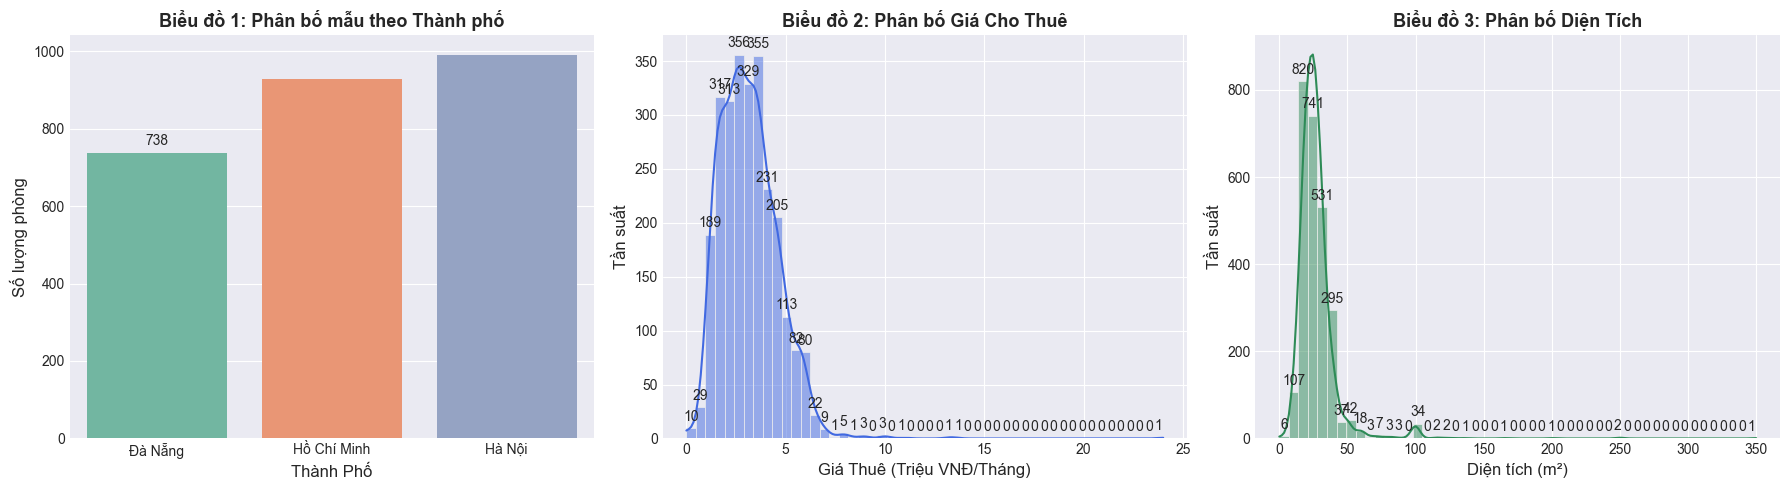

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách biểu đồ
plt.rcParams['font.family'] = 'sans-serif'
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Figure 1: Số lượng phòng trọ theo thành phố
sns.countplot(x='Thành_Phố', data=df_raw, palette='Set2', ax=axes[0])
axes[0].set_title('Biểu đồ 1: Phân bố mẫu theo Thành phố', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng phòng')
axes[0].set_xlabel('Thành Phố')
axes[0].bar_label(axes[0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# Biểu đồ 2: Phân bố Giá cho thuê (Histogram + KDE)
sns.histplot(df_raw['Giá_Cho_Thuê'], bins=50, kde=True, color='royalblue', ax=axes[1])
axes[1].set_title('Biểu đồ 2: Phân bố Giá Cho Thuê', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá Thuê (Triệu VNĐ/Tháng)')
axes[1].set_ylabel('Tần suất')
axes[1].bar_label(axes[1].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# Biểu đồ 3: Phân bố Diện tích (Histogram + KDE)
sns.histplot(df_raw['Diện_Tích_m2'], bins=50, kde=True, color='seagreen', ax=axes[2])
axes[2].set_title('Biểu đồ 3: Phân bố Diện Tích', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Diện tích (m²)')
axes[2].set_ylabel('Tần suất')
axes[2].bar_label(axes[2].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

plt.tight_layout()
plt.show()

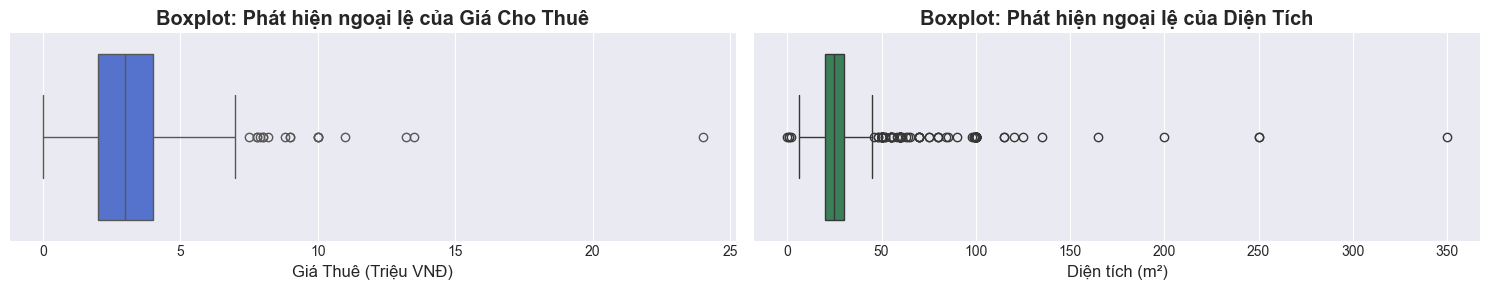

In [25]:
# Khởi tạo khung vẽ gồm 2 biểu đồ Boxplot
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

# Boxplot cho Giá cho thuê
sns.boxplot(x=df_raw['Giá_Cho_Thuê'], color='royalblue', ax=axes[0])
axes[0].set_title('Boxplot: Phát hiện ngoại lệ của Giá Cho Thuê', fontweight='bold')
axes[0].set_xlabel('Giá Thuê (Triệu VNĐ)')

# Boxplot cho Diện tích
sns.boxplot(x=df_raw['Diện_Tích_m2'], color='seagreen', ax=axes[1])
axes[1].set_title('Boxplot: Phát hiện ngoại lệ của Diện Tích', fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')

plt.tight_layout()
plt.show()

**Nhận xét từ biểu đồ phân tích đơn biến:**

**1. Về phân bổ khu vực (Biều đồ 1):** Số lượng mẫu thu thập được phân bổ tương đối đồng đều ở các thành phố lớn (Hà Nội, TP.HCM, Đà Nẵng), đảm bảo tính đại diện cho mặt bằng chung của thị trường phòng trọ sinh viên.
**2. Về phân bố hình dáng (Biểu đồ 2 & 3):** 
- Cả hai biến `Giá_Cho_Thuê` và `Diện_Tích_m2` đều **không tuân theo phân phối chuẩn (Normal Distribution)**. Đường cong KDE cho thấy dữ liệu bị lệch phải rất nặng.
- Nguyên nhân: Phần lớn phòng trọ sinh viên tập trung ở phân khúc giá rẻ (2 - 5 triệu) và diện tích nhỏ (15 - 30 m2). Tuy nhiên, có một số lượng nhỏ các căn hộ dịch vụ cao cấp hoặc nhà nguyên căn, hoặc đơn giản là dữ liệu bị sai nên giá và diện tích kéo dài chiếc đuôi của đồ thị về phía bên phải.

**3. Về Ngoại lệ / Outlier:**
- Biểu đổ Boxplot xuât hiện rất nhiều điểm đen (outliers) nằm ngoài râu của đồ thị. Tồn tại các điểm dữ liệu bất hợp lý (Giá thuê = 0 đồng hoặc Diện tích 350 m2). Những dữ liệu rác này nếu đưa thẳng vào mô hình Hồi quy sẽ làm giảm độ chính xác và gây ra hiện tượng thiên kiến.

## 4. Làm sạch và Chuẩn hóa dữ liệu

### 4.1 Tiền xử lý dữ liệu (Data Preprocessing)
Dựa trên những phát hiện từ quá trình Khám phá dữ liệu, nhóm tiến hành tiền xử lý theo 3 bước tuần tự nhằm đảm bảo chất lượng dữ liệu tốt nhất trước khi đưa vào mô hình hóa:

**1. Trích xuất đặc trưng (Feature Engineering)**
- **Vấn đề:** Các tiện ích phòng trọ đang nằm dưới dạng văn bản phi cấu trúc tại cột `Mô_Tả`, `Nổi_Bật` và `Tiêu_Đề`.
- **Cách xử lý:** Sử dụng Biểu thức chính quy (Regex) để quét và bóc tách văn bản thành 10 biến tiện ích nhị phân (0/1). Sau đó, xóa bỏ các cột văn bản thô để tối ưu hóa bộ nhớ.

**2. Làm sạch dữ liệu ngoại lệ (Outlier)**
- **Vấn đề:** Biểu đồ Boxplot trước đó cho thấy sự xuất hiện của các điểm dữ liệu nhiễu (Giá = 0 đồng) và các ngoại lệ quá lớn (Nhà nguyên căn, căn hộ dịch vụ bị nhầm lẫn vào dữ liệu phòng trọ sinh viên hoặc bị nhầm lẫn khi nhập liệu).
- **Cách xử lý:** Quyết định chỉ giữ lại các phòng trọ có `Giá từ 0.5 - 7 triệu/tháng` và `Diện tích từ 8 - 50 m2`. 

**3. Chuẩn hóa dữ liệu**
- **Vấn đề:** Biểu đồ Histogram cho thấy phân bố của Giá và Diện tích bị **lệch phải nghiêm trọng**, vi phạm giả định phân phối chuẩn của mô hình hồi quy tuyến tính.
- **Cách xử lý:** Áp dụng phép biến đổi logarit tự nhiên `np.log1p()` để co hẹp khoảng cách của các giá trị lớn, kéo phân phối của dữ liệu về sát với dạng hình quả chuông (Normal Distribution).

### Trích xuất đặc trưng (Feature Engineering) và Xóa Outliers

In [46]:
import re
import numpy as np

In [47]:
# Xử lý Missing Values ở các cột văn bản bằng cách điền chuỗi rỗng
df_raw['Tiêu_Đề'] = df_raw['Tiêu_Đề'].fillna('')
df_raw['Mô_Tả'] = df_raw['Mô_Tả'].fillna('')
df_raw['Nổi_Bật'] = df_raw['Nổi_Bật'].fillna('')

# Gộp các cột văn bản thành một cột duy nhất để không bị sót thông tin
df_raw['Full_Text'] = df_raw['Tiêu_Đề'] + ' ' + df_raw['Mô_Tả'] + ' ' + df_raw['Nổi_Bật']

In [49]:
# Hàm bóc tách dựa trên Regex 
def extract_utilities(text_content):
    d = str(text_content).lower()
    return pd.Series({
        "Máy_Lạnh": 1 if re.search(r'(máy lạnh|điều hòa|điều hoà)', d) else 0,
        "Nóng_Lạnh": 1 if re.search(r'(nóng lạnh|máy nước nóng|bình nước nóng)', d) else 0,
        "Thang_Máy": 1 if re.search(r'(thang máy)', d) else 0,
        "Tủ_Lạnh": 1 if re.search(r'(tủ lạnh)', d) else 0,
        "Máy_Giặt": 1 if re.search(r'(máy giặt)', d) else 0,
        "Đầy_Đủ_Nội_Thất": 1 if re.search(r'(đầy đủ nội thất|full nội thất|nội thất đầy đủ)', d) else 0,
        "Có_Gác_Lửng": 1 if re.search(r'(có gác|gác lửng|gác xép)', d) else 0,
        "Bảo_Vệ_An_Ninh": 1 if re.search(r'(bảo vệ|an ninh|camera)', d) else 0,
        "Giờ_Tự_Do": 1 if re.search(r'(giờ giấc tự do|giờ tự do|chìa khóa trao tay|giờ giấc thoải mái)', d) else 0,
        "Không_Chung_Chủ": 1 if re.search(r'(không chung chủ|lối đi riêng)', d) else 0
    })

In [50]:
features_df = df_raw['Full_Text'].apply(extract_utilities)
df_clean = pd.concat([df_raw, features_df], axis=1)

In [51]:
# Xóa bỏ các cột văn bản và cột định danh không cần thiết
cols_to_drop = ['Mã_Tin', 'Thời_Gian_Đăng', 'Tiêu_Đề', 'Mô_Tả', 'Nổi_Bật', 'Full_Text']
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"Kích thước sau Feature Engineering: {df_clean.shape[0]} mẫu, {df_clean.shape[1]} biến.")

df_clean = df_clean[(df_clean['Giá_Cho_Thuê'] >= 0.5) & (df_clean['Giá_Cho_Thuê'] <= 7)]
df_clean = df_clean[(df_clean['Diện_Tích_m2'] >= 8) & (df_clean['Diện_Tích_m2'] <= 50)]

print(f"Kích thước sau khi Outliers: {df_clean.shape[0]} mẫu, {df_clean.shape[1]} biến.")

Kích thước sau Feature Engineering: 2657 mẫu, 14 biến.
Kích thước sau khi Outliers: 2542 mẫu, 14 biến.


### Chuẩn hóa logarit & Trực quan hóa so sánh

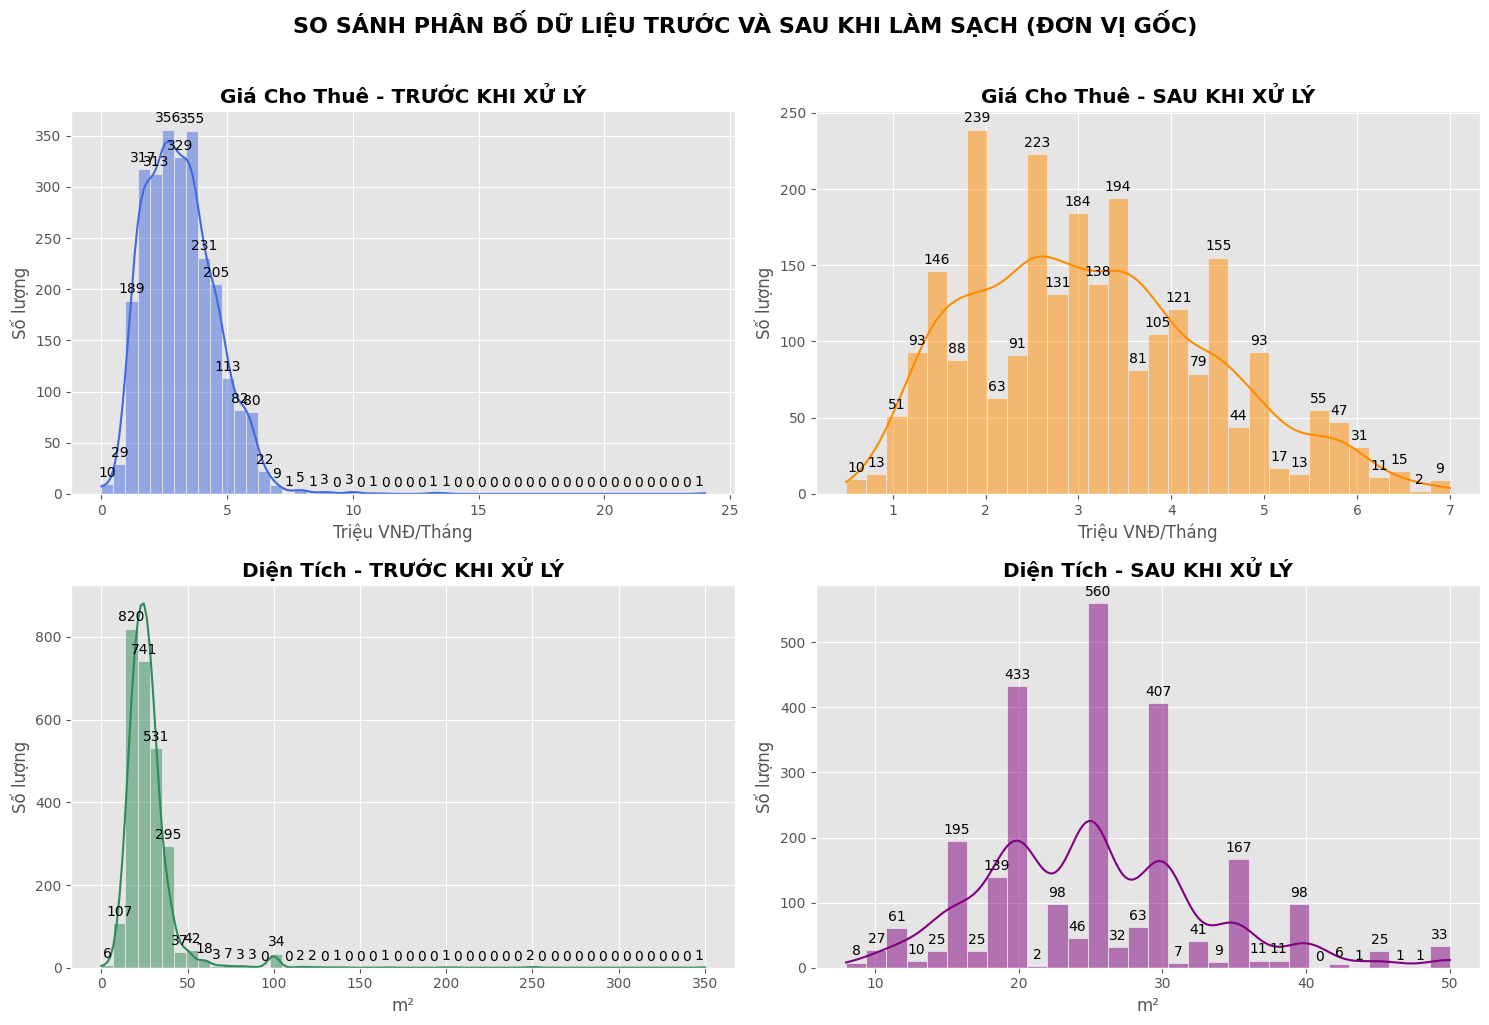

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# So sánh phân bố dữ liệu trước và sau khi làm sạch bằng biểu đồ histogram kết hợp KDE
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SO SÁNH PHÂN BỐ DỮ LIỆU TRƯỚC VÀ SAU KHI LÀM SẠCH (ĐƠN VỊ GỐC)', fontsize=16, fontweight='bold', y=1.02)

# --- HÀNG 1: GIÁ CHO THUÊ ---
sns.histplot(df_raw['Giá_Cho_Thuê'], bins=50, kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('Giá Cho Thuê - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0, 0].set_xlabel('Triệu VNĐ/Tháng')
axes[0, 0].set_ylabel('Số lượng')
axes[0, 0].bar_label(axes[0, 0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

sns.histplot(df_clean['Giá_Cho_Thuê'], bins=30, kde=True, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Giá Cho Thuê - SAU KHI XỬ LÝ', fontweight='bold')
axes[0, 1].set_xlabel('Triệu VNĐ/Tháng')
axes[0, 1].set_ylabel('Số lượng')
axes[0, 1].bar_label(axes[0, 1].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

# --- HÀNG 2: DIỆN TÍCH ---
sns.histplot(df_raw['Diện_Tích_m2'], bins=50, kde=True, color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Diện Tích - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[1, 0].set_xlabel('m²')
axes[1, 0].set_ylabel('Số lượng')
axes[1, 0].bar_label(axes[1, 0].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột

sns.histplot(df_clean['Diện_Tích_m2'], bins=30, kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Diện Tích - SAU KHI XỬ LÝ', fontweight='bold')
axes[1, 1].set_xlabel('m²')
axes[1, 1].set_ylabel('Số lượng')
axes[1, 1].bar_label(axes[1, 1].containers[0], padding=3) # Hiển thị số lượng cụ thể trên đỉnh cột


plt.tight_layout()
plt.show()

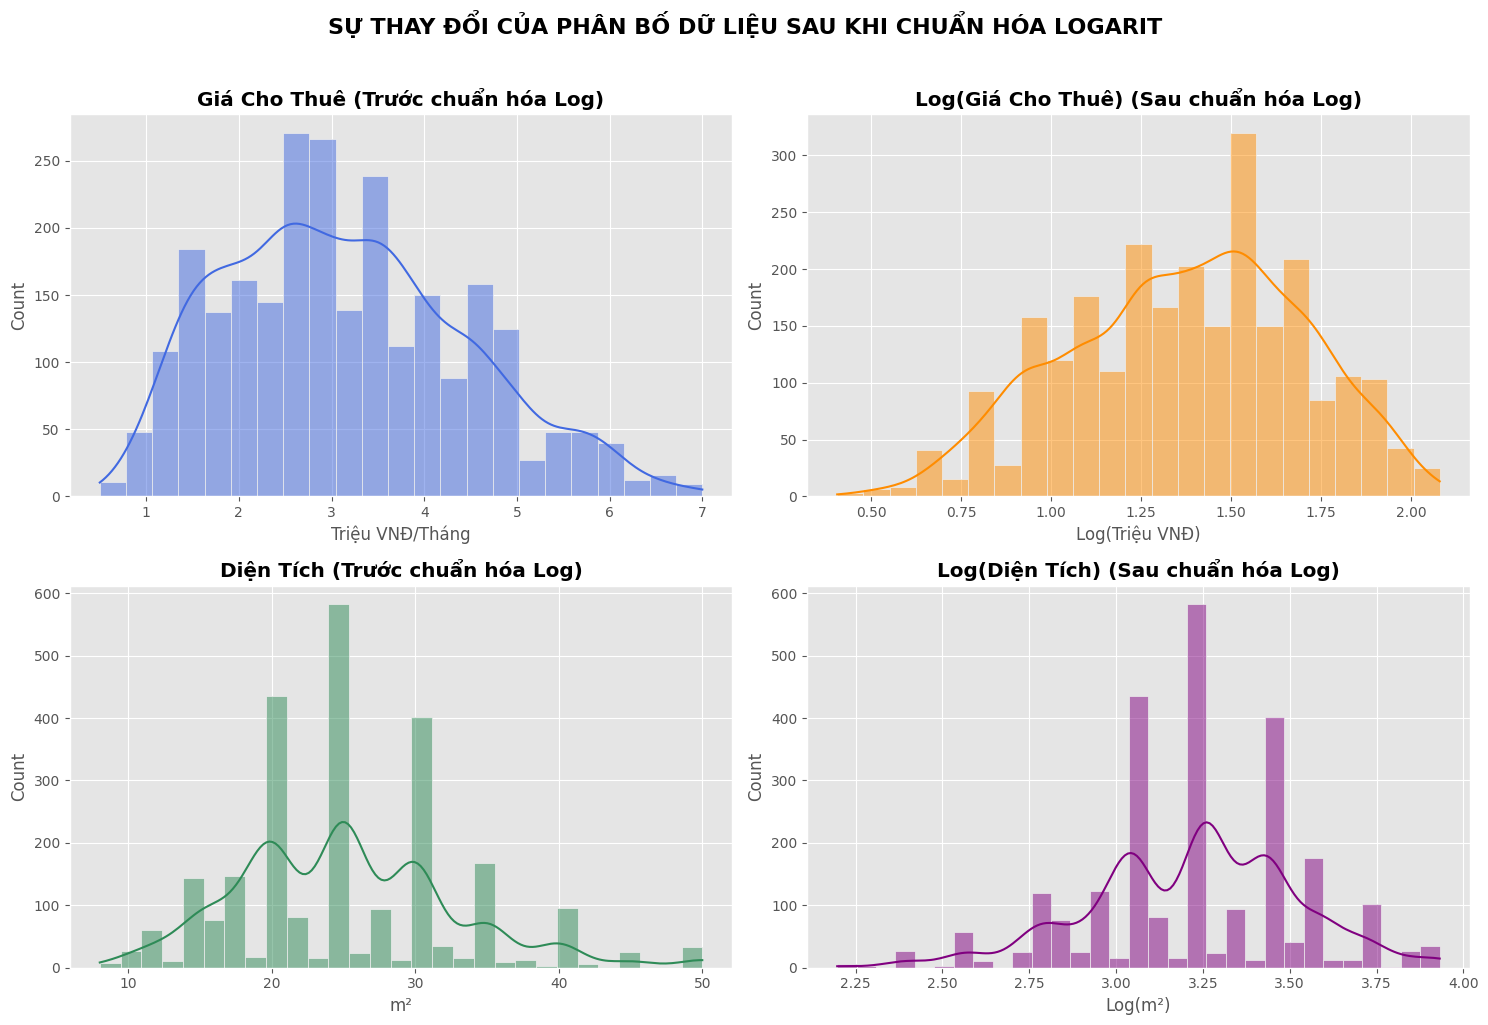

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Áp dụng hàm log1p (Logarit tự nhiên của 1 + x)
df_clean['Log_Giá'] = np.log1p(df_clean['Giá_Cho_Thuê'])
df_clean['Log_Diện_Tích'] = np.log1p(df_clean['Diện_Tích_m2'])

# VẼ BIỂU ĐỒ SO SÁNH TRƯỚC VÀ SAU KHI CHUẨN HÓA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('SỰ THAY ĐỔI CỦA PHÂN BỐ DỮ LIỆU SAU KHI CHUẨN HÓA LOGARIT', fontsize=16, fontweight='bold', y=1.02)

# --- Hàng 1: Giá Cho Thuê ---
sns.histplot(df_clean['Giá_Cho_Thuê'], kde=True, color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('Giá Cho Thuê (Trước chuẩn hóa Log)', fontweight='bold')
axes[0, 0].set_xlabel('Triệu VNĐ/Tháng')

sns.histplot(df_clean['Log_Giá'], kde=True, color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Log(Giá Cho Thuê) (Sau chuẩn hóa Log)', fontweight='bold')
axes[0, 1].set_xlabel('Log(Triệu VNĐ)')

# --- Hàng 2: Diện Tích ---
sns.histplot(df_clean['Diện_Tích_m2'], kde=True, color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Diện Tích (Trước chuẩn hóa Log)', fontweight='bold')
axes[1, 0].set_xlabel('m²')

sns.histplot(df_clean['Log_Diện_Tích'], kde=True, color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Log(Diện Tích) (Sau chuẩn hóa Log)', fontweight='bold')
axes[1, 1].set_xlabel('Log(m²)')

plt.tight_layout()
plt.show()

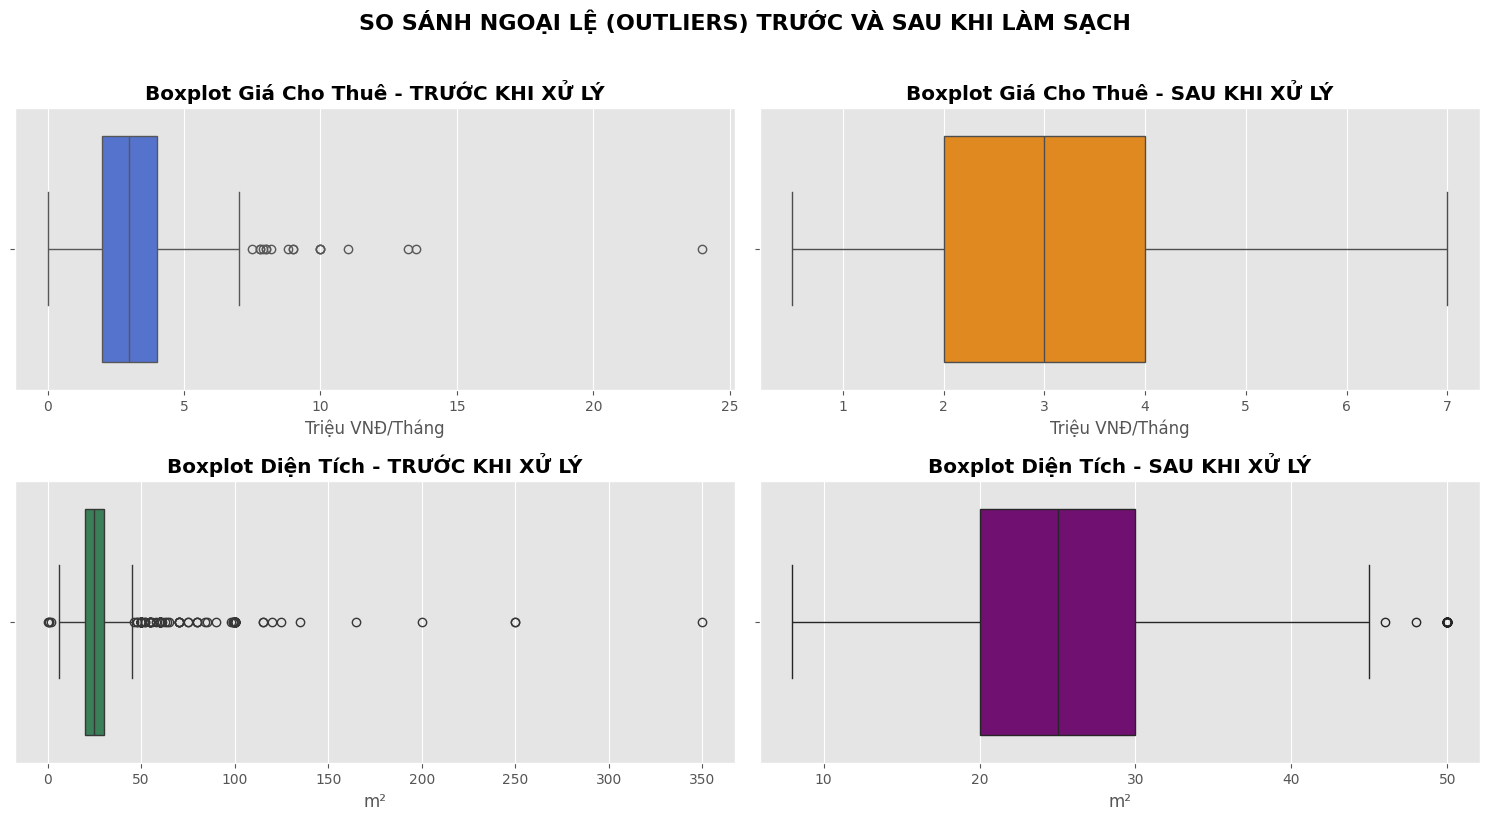

In [55]:
# So sánh ngoại lệ bằng Boxplot trước và sau khi làm sạch dữ liệu
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('SO SÁNH NGOẠI LỆ (OUTLIERS) TRƯỚC VÀ SAU KHI LÀM SẠCH', fontsize=16, fontweight='bold', y=1.02)

# Hàng 1: Giá cho thuê
sns.boxplot(x=df_raw['Giá_Cho_Thuê'], color='royalblue', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot Giá Cho Thuê - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0, 0].set_xlabel('Triệu VNĐ/Tháng')

sns.boxplot(x=df_clean['Giá_Cho_Thuê'], color='darkorange', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot Giá Cho Thuê - SAU KHI XỬ LÝ', fontweight='bold')
axes[0, 1].set_xlabel('Triệu VNĐ/Tháng')

# Hàng 2: Diện tích
sns.boxplot(x=df_raw['Diện_Tích_m2'], color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot Diện Tích - TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[1, 0].set_xlabel('m²')

sns.boxplot(x=df_clean['Diện_Tích_m2'], color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot Diện Tích - SAU KHI XỬ LÝ', fontweight='bold')
axes[1, 1].set_xlabel('m²')

plt.tight_layout()
plt.show()

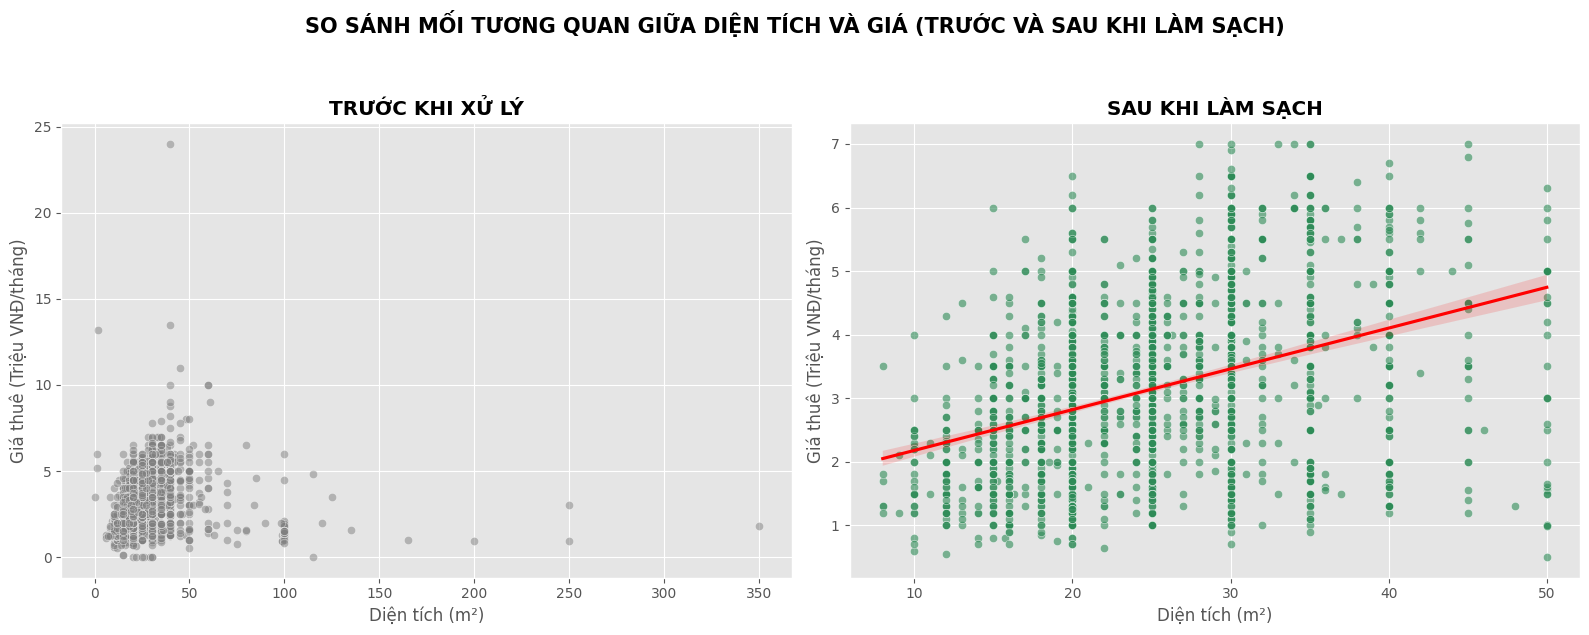

In [56]:
# So sánh mối quan hệ tương quan giữa Diện tích và Giá cho thuê trước và sau khi làm sạch dữ liệu
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SO SÁNH MỐI TƯƠNG QUAN GIỮA DIỆN TÍCH VÀ GIÁ (TRƯỚC VÀ SAU KHI LÀM SẠCH)', fontsize=15, fontweight='bold', y=1.05)

# 1. Trước khi xử lý (df_raw)
sns.scatterplot(x='Diện_Tích_m2', y='Giá_Cho_Thuê', data=df_raw, alpha=0.5, color='gray', ax=axes[0])
axes[0].set_title('TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0].set_xlabel('Diện tích (m²)')
axes[0].set_ylabel('Giá thuê (Triệu VNĐ/tháng)')

# 2. Sau khi xử lý (df_clean)
sns.scatterplot(x='Diện_Tích_m2', y='Giá_Cho_Thuê', data=df_clean, alpha=0.6, color='seagreen', ax=axes[1])
sns.regplot(x='Diện_Tích_m2', y='Giá_Cho_Thuê', data=df_clean, scatter=False, color='red', ax=axes[1])
axes[1].set_title('SAU KHI LÀM SẠCH', fontweight='bold')
axes[1].set_xlabel('Diện tích (m²)')
axes[1].set_ylabel('Giá thuê (Triệu VNĐ/tháng)')

plt.tight_layout()
plt.show()

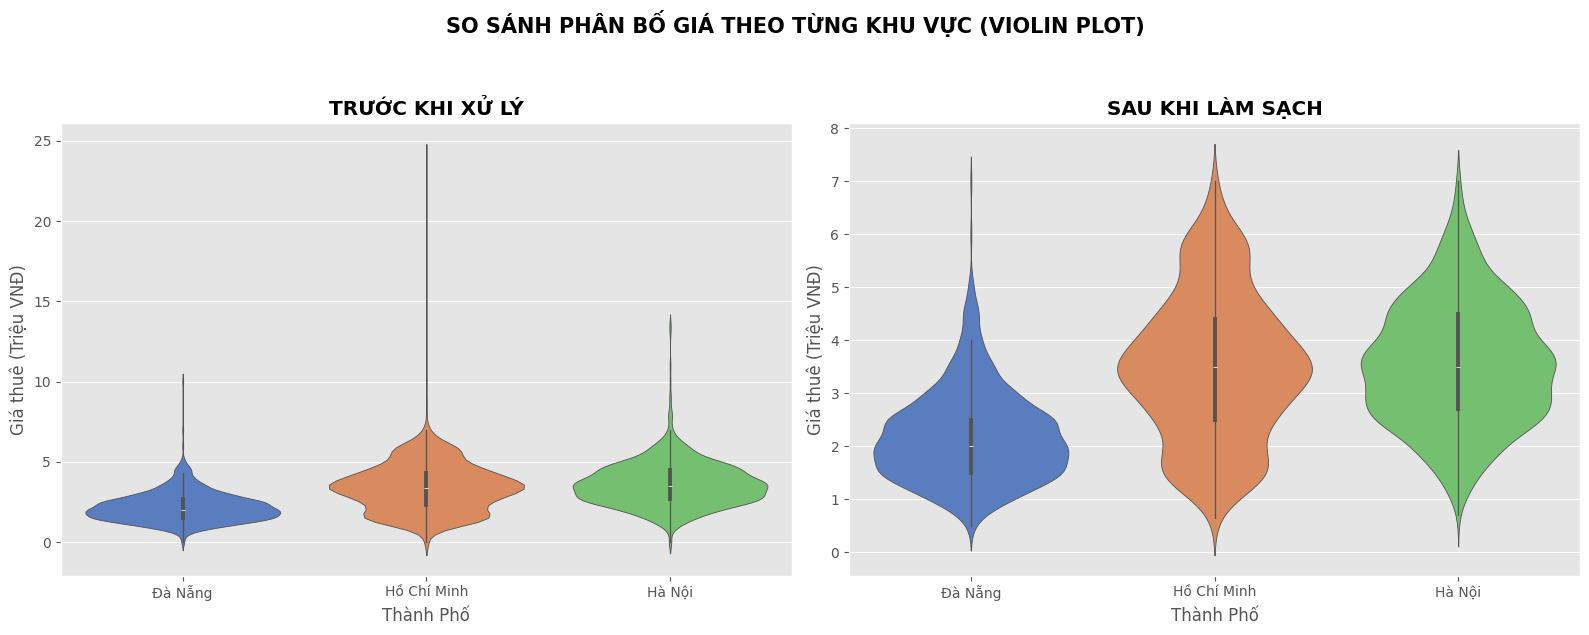

In [57]:
# So sánh phân bố theo thành phố bằng violin plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SO SÁNH PHÂN BỐ GIÁ THEO TỪNG KHU VỰC (VIOLIN PLOT)', fontsize=15, fontweight='bold', y=1.05)

# 1. Trước khi xử lý
sns.violinplot(x='Thành_Phố', y='Giá_Cho_Thuê', data=df_raw, palette='muted', ax=axes[0])
axes[0].set_title('TRƯỚC KHI XỬ LÝ', fontweight='bold')
axes[0].set_xlabel('Thành Phố')
axes[0].set_ylabel('Giá thuê (Triệu VNĐ)')

# 2. Sau khi xử lý
sns.violinplot(x='Thành_Phố', y='Giá_Cho_Thuê', data=df_clean, palette='muted', ax=axes[1])
axes[1].set_title('SAU KHI LÀM SẠCH', fontweight='bold')
axes[1].set_xlabel('Thành Phố')
axes[1].set_ylabel('Giá thuê (Triệu VNĐ)')

plt.tight_layout()
plt.show()

## Phân tích tác động của các Tiện ích đến Giá cho thuê phòng trọ

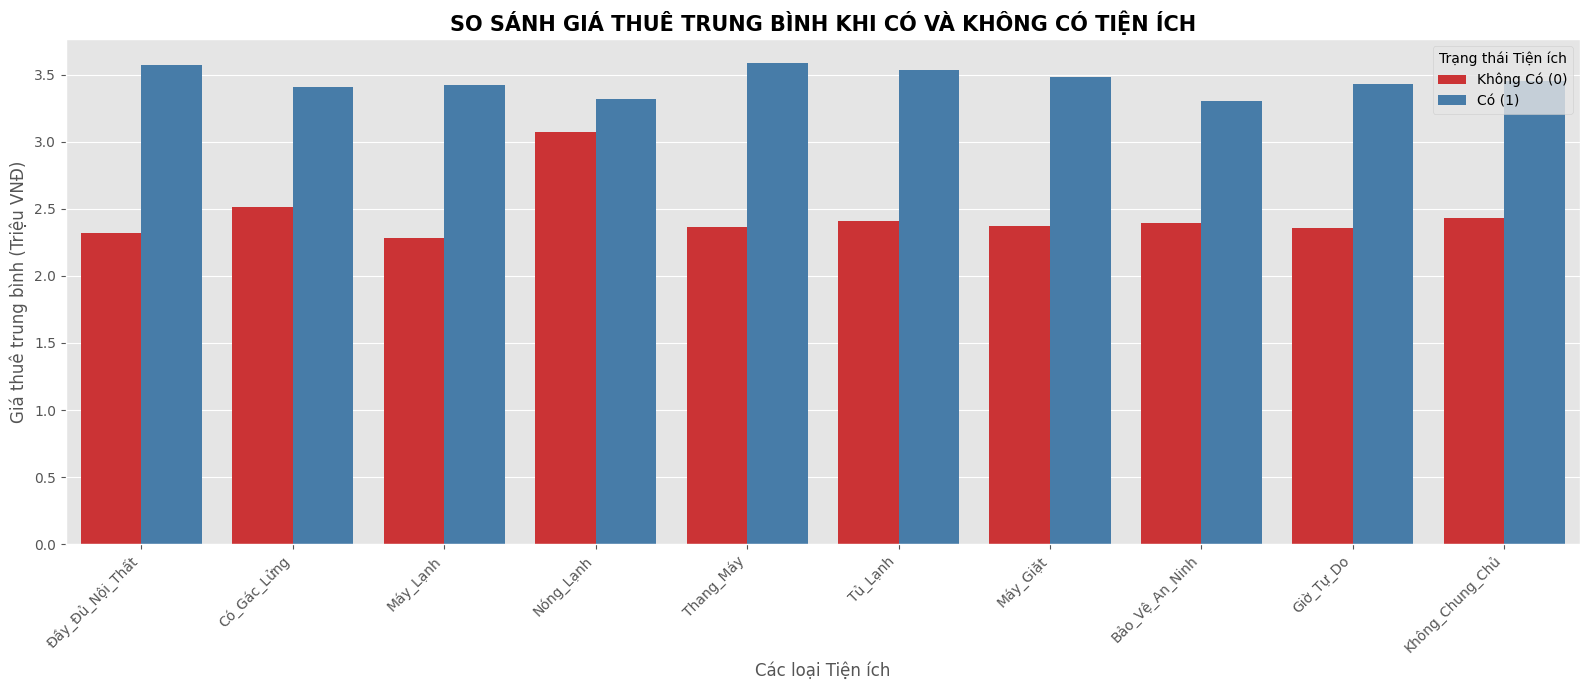

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Danh sách 10 cột tiện ích
utility_cols = ['Đầy_Đủ_Nội_Thất', 'Có_Gác_Lửng', 'Máy_Lạnh', 'Nóng_Lạnh', 
                'Thang_Máy', 'Tủ_Lạnh', 'Máy_Giặt', 'Bảo_Vệ_An_Ninh', 'Giờ_Tự_Do', 'Không_Chung_Chủ']

# Tạo một bảng Dataframe mới để tính giá trung bình
utility_price_data = []

for col in utility_cols:
    # Giá trung bình khi Không có tiện ích (0)
    price_0 = df_clean[df_clean[col] == 0]['Giá_Cho_Thuê'].mean()
    # Giá trung bình khi Có tiện ích (1)
    price_1 = df_clean[df_clean[col] == 1]['Giá_Cho_Thuê'].mean()
    
    utility_price_data.append({'Tiện_Ích': col, 'Trạng_Thái': 'Không Có (0)', 'Giá_Trung_Bình': price_0})
    utility_price_data.append({'Tiện_Ích': col, 'Trạng_Thái': 'Có (1)', 'Giá_Trung_Bình': price_1})

df_utility_price = pd.DataFrame(utility_price_data)

# Vẽ biểu đồ
plt.figure(figsize=(16, 7))
sns.barplot(x='Tiện_Ích', y='Giá_Trung_Bình', hue='Trạng_Thái', data=df_utility_price, palette='Set1')

plt.title('SO SÁNH GIÁ THUÊ TRUNG BÌNH KHI CÓ VÀ KHÔNG CÓ TIỆN ÍCH', fontsize=15, fontweight='bold')
plt.xlabel('Các loại Tiện ích')
plt.ylabel('Giá thuê trung bình (Triệu VNĐ)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Trạng thái Tiện ích')
plt.tight_layout()
plt.show()

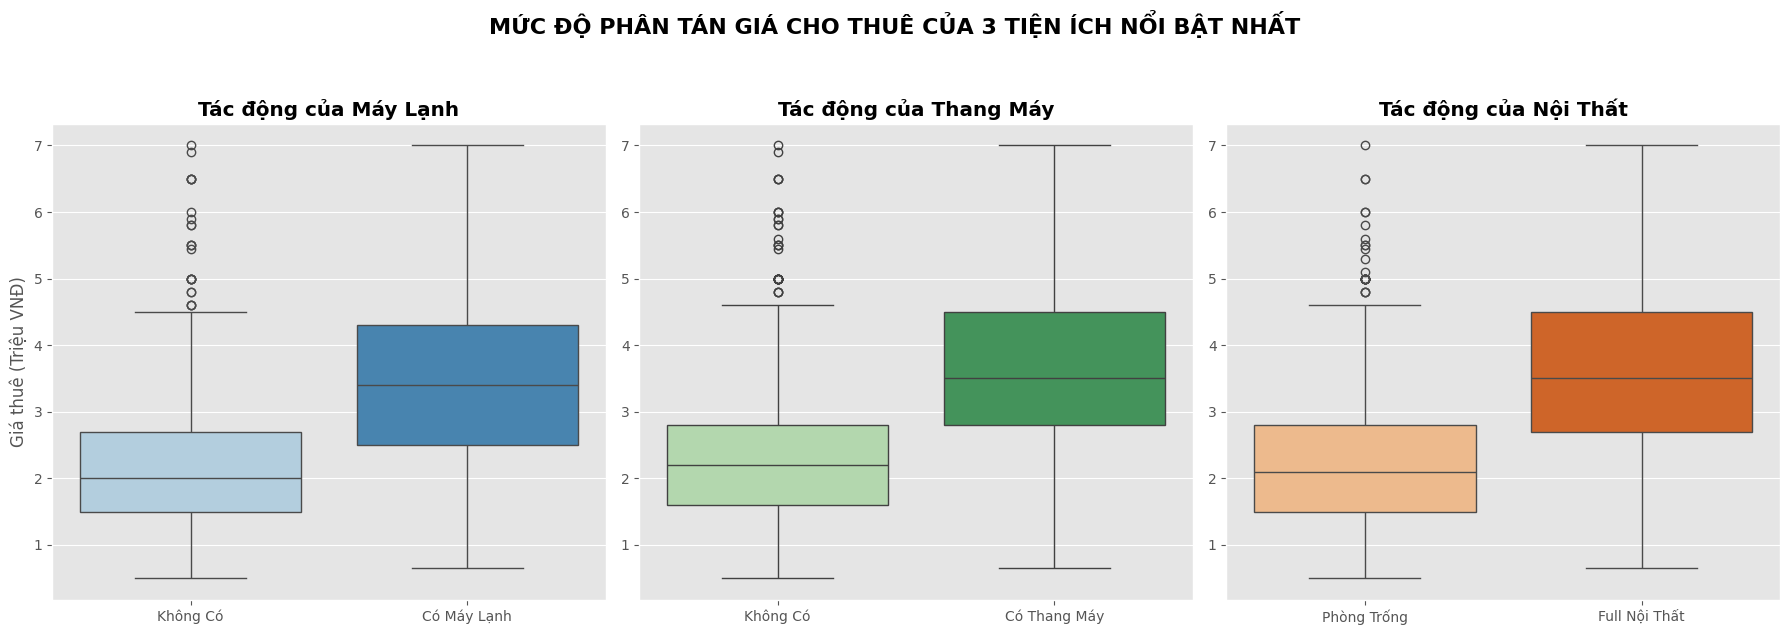

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('MỨC ĐỘ PHÂN TÁN GIÁ CHO THUÊ CỦA 3 TIỆN ÍCH NỔI BẬT NHẤT', fontsize=16, fontweight='bold', y=1.05)

# 1. Máy Lạnh
sns.boxplot(x='Máy_Lạnh', y='Giá_Cho_Thuê', data=df_clean, palette='Blues', ax=axes[0])
axes[0].set_title('Tác động của Máy Lạnh', fontweight='bold')
axes[0].set_xticklabels(['Không Có', 'Có Máy Lạnh'])
axes[0].set_ylabel('Giá thuê (Triệu VNĐ)')
axes[0].set_xlabel('')

# 2. Thang Máy
sns.boxplot(x='Thang_Máy', y='Giá_Cho_Thuê', data=df_clean, palette='Greens', ax=axes[1])
axes[1].set_title('Tác động của Thang Máy', fontweight='bold')
axes[1].set_xticklabels(['Không Có', 'Có Thang Máy'])
axes[1].set_ylabel('')
axes[1].set_xlabel('')

# 3. Đầy Đủ Nội Thất
sns.boxplot(x='Đầy_Đủ_Nội_Thất', y='Giá_Cho_Thuê', data=df_clean, palette='Oranges', ax=axes[2])
axes[2].set_title('Tác động của Nội Thất', fontweight='bold')
axes[2].set_xticklabels(['Phòng Trống', 'Full Nội Thất'])
axes[2].set_ylabel('')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

### Nhận xét và đánh giá sau khi làm sạch và chuẩn hóa dữ liệu:
Thông qua các biểu đồ so sánh trực quan giữa dữ liệu gốc (Raw Data) và dữ liệu sau khi làm sạch (Clean Data), rút ra những nhận xét sau:

**1. Về sự thay đổi của Phân phối (Đồ thị Histogram)**
- Trước khi làm sạch, đồ thị bị bóp mém - bởi các giá trị dị biệt (phòng có giá 24 triệu/tháng, rộng 350 m2).
- Sau khi loại bỏ ngoại lệ (giữ mức 0.5 - 7 triệu và 8 - 50 m2), dữ liệu đã tập trung vào đúng phân khúc phòng trọ sinh viên.
- **Tác dụng của chuẩn hóa Logarit:** Khi áp dụng phép biến đổi Logarit (`Log_Giá` và `Log_Diện_Tích`), đồ thị từ trạng thái Lệch phải đã được kéo về trạng thái cân xứng hình quả chuông (Phân phối chuẩn).

**2. Về sự rõ nét của xu hướng tuyến tính (Đồ thị Scatter Plot)**
- Biểu đồ phân tán minh chứng cho hiệu quả của việc cắt xén. Ở dữ liệu gốc, các điểm Outlier làm mờ đi quy luật của tập dữ liệu.
- Trong khi đó, ở đồ thị Clean Data, một **đường xu hướng tuyến tính đồng biến** hiện ra rõ rệt: Diện tích tỉ lệ thuận với Giá thuê. Các điểm dữ liệu bám khá sát xung quanh đường xu hướng này.

**3. Về cấu trúc giá theo khu vực (Đồ thị Violin Plot)**
- Đồ thị vĩ cầm của tập dữ liệu sạch cho thấy bức tranh thị trường rõ rệt.
- **Đà Nẵng**: Phần bụng vĩ cầm phình to ở mốc giá thấp (2 - 3 triệu) và thuôn nhọn rất nhanh, chứng tỏ mặt bằng giá ở đây rẻ và ít sự phân hóa.
- **Hà Nội & TP.HCM**: Phân thân vĩ cầm kéo dài và trải rộng ở mốc từ 3 - 5 triệu, cho thấy mức giá cao hơn và thị trường có rất nhiều phân khúc đa dạng.

**4. Về tác động của Tiện ích**
- **Từ biểu đồ cột:** 
    + Hầu hết mọ tiện ích đều làm tăng giá trị của căn phòng. Các cột màu đỏ (Có tiện ích) luôn cao hơn cột màu xanh (Không có tiện ích).
    + Tuy nhiên, mức độ tác động không đồng đều. Các tiện ích cốt lõi thuộc về cấu trúc và đầu tư lớn như: **Thang_Máy**, **Nóng_Lạnh**, **Đầy_Đủ_Nội_Thất** tạo ra khoảng chênh lệch giá lớn nhất.
    + Ngược lại, những tiện ích mang tính quy định như **Giờ_Tự_Do**, **Không_Chung_Chủ**, **Có_Gác_Lửng** ít tạo ra sự đột biến về giá vì chúng thường là tiêu chuẩn chung của các phòng trọ sinh viên hiện nay.

- **Từ biểu đồ Boxplot (Top 3 tiện ích)**
    + Sự khác biệt về mặt bằng giá cực kỳ rõ ràng. Với các phòng không có Thang máy hoặc không có Máy lạnh, đồ thị Boxplot bị ép xuống rất thấp, mức quá kịch trần thường không vượt quá 3-4 triệu.
    + Khi được trang bị Full nội thất hoặc Thang máy, không chỉ mức giá trung bình (đường kẻ ngang trong hộp) tăng lên, mà toàn bộ dải phân bố giá cũng được kéo dài lên phân khúc 4 - 7 triệu.

### Xuất file Dữ liệu sạch (Clean Data)

In [58]:
first_cols = ['Thành_Phố', 'Quận_Huyện', 'Giá_Cho_Thuê', 'Log_Giá', 'Diện_Tích_m2', 'Log_Diện_Tích']
utility_cols = [c for c in df_clean.columns if c not in first_cols]

final_cols = first_cols + utility_cols
df_clean = df_clean[final_cols]

# Export data after cleaning
file_clean_path = '../data_phongtro/clean_data.csv'
df_clean.to_csv(file_clean_path, index=False, encoding='utf-8-sig')

print(f"Lưu thành công dữ liệu sạch vào: {file_clean_path} với {df_clean.shape[0]} mẫu và {df_clean.shape[1]} biến.")

Lưu thành công dữ liệu sạch vào: ../data_phongtro/clean_data.csv với 2542 mẫu và 16 biến.


### Lấy ra 5 dòng đầu tiên của file sau khi đã làm sạch

In [60]:
display(df_clean.head(5))

,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Log_Giá,Diện_Tích_m2,Log_Diện_Tích,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ
0,Đà Nẵng,Liên Chiểu,2.7,1.308333,18.0,2.944439,1,0,1,1,1,1,1,1,1,1
1,Đà Nẵng,Hải Châu,4.0,1.609438,30.0,3.433987,1,0,1,1,1,1,1,1,1,1
2,Đà Nẵng,Hải Châu,1.7,0.993252,18.0,2.944439,0,0,0,0,0,0,0,0,0,0
3,Đà Nẵng,Cẩm Lệ,3.3,1.458615,20.0,3.044522,1,0,1,1,1,1,1,1,1,1
4,Đà Nẵng,Ngũ Hành Sơn,2.0,1.098612,20.0,3.044522,1,0,1,1,1,1,1,1,1,1


In [61]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2542 entries, 0 to 2656
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Thành_Phố        2542 non-null   str    
 1   Quận_Huyện       2542 non-null   str    
 2   Giá_Cho_Thuê     2542 non-null   float64
 3   Log_Giá          2542 non-null   float64
 4   Diện_Tích_m2     2542 non-null   float64
 5   Log_Diện_Tích    2542 non-null   float64
 6   Máy_Lạnh         2542 non-null   int64  
 7   Nóng_Lạnh        2542 non-null   int64  
 8   Thang_Máy        2542 non-null   int64  
 9   Tủ_Lạnh          2542 non-null   int64  
 10  Máy_Giặt         2542 non-null   int64  
 11  Đầy_Đủ_Nội_Thất  2542 non-null   int64  
 12  Có_Gác_Lửng      2542 non-null   int64  
 13  Bảo_Vệ_An_Ninh   2542 non-null   int64  
 14  Giờ_Tự_Do        2542 non-null   int64  
 15  Không_Chung_Chủ  2542 non-null   int64  
dtypes: float64(4), int64(10), str(2)
memory usage: 337.6 KB


In [63]:
df_clean.describe().round(2)

,Giá_Cho_Thuê,Log_Giá,Diện_Tích_m2,Log_Diện_Tích,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ
count,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00,2542.00
mean,3.15,1.37,25.14,3.22,0.76,0.31,0.64,0.66,0.70,0.66,0.71,0.83,0.74,0.70
std,1.31,0.32,7.70,0.30,0.43,0.46,0.48,0.47,0.46,0.47,0.46,0.37,0.44,0.46
min,0.50,0.41,8.00,2.20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2.00,1.10,20.00,3.04,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
50%,3.00,1.39,25.00,3.26,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
75%,4.00,1.61,30.00,3.43,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
max,7.00,2.08,50.00,3.93,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
